In [5]:
pip install rioxarray python-docx pcse

Note: you may need to restart the kernel to use updated packages.


# **LUE Constant Productivity**

Membaca file mask sawah lokal sebagai AOI...
Menjalankan model Light Use Efficiency (LUE) untuk estimasi hasil padi...
Mengunduh dan menyatukan tile untuk: _temp_raw_download.tif...

HASIL ANALISIS PRODUKTIVITAS & PRODUKSI:
* Total Luas Sawah Aktif : 7,257.59 Ha
* Rata-rata Produktivitas  : 9.73 Ton/Ha
* TOTAL PRODUKSI PADINYA   : 70,644.61 Ton

Membuat GeoJSON estimasi produktivitas (nilai kontinu)...
-> GeoJSON estimasi produktivitas tersimpan: ../../data/processed\module_4\estimasi_produktivitas_padi.geojson (55137 fitur, sel 50m)

Membuat GeoJSON kelas klasifikasi produktivitas...
-> GeoJSON kelas klasifikasi tersimpan: ../../data/processed\module_4\kelas_klasifikasi_produktivitas.geojson (3 fitur)
   Ambang kelas -> Rendah: <7.59 | Sedang: 7.59-12.74 | Tinggi: >12.74 ton/ha

Membuat grafik distribusi hasil...


## Hasil Kalkulasi Total Produksi Padi (Level-0 LUE)

* **Total Luas Sawah Aktif:** `7,257.59 Ha`

* **Rata-rata Produktivitas:** `9.73 Ton/Ha`

* **TOTAL PRODUKSI KUMULATIF:** `70,644.61 Ton`

### Output 1 - GeoJSON Estimasi Produktivitas (preview atribut)

,geometry,yield_ton_ha
0,"POLYGON ((112.36818 -7.06304, 112.36818 -7.063...",15.239
1,"POLYGON ((112.36863 -7.06304, 112.36863 -7.063...",13.015
2,"POLYGON ((112.36908 -7.06304, 112.36908 -7.063...",15.506
3,"POLYGON ((112.36953 -7.06304, 112.36953 -7.063...",15.503
4,"POLYGON ((112.36999 -7.06304, 112.36999 -7.063...",15.231


### Output 1 (peta) - Estimasi Produktivitas

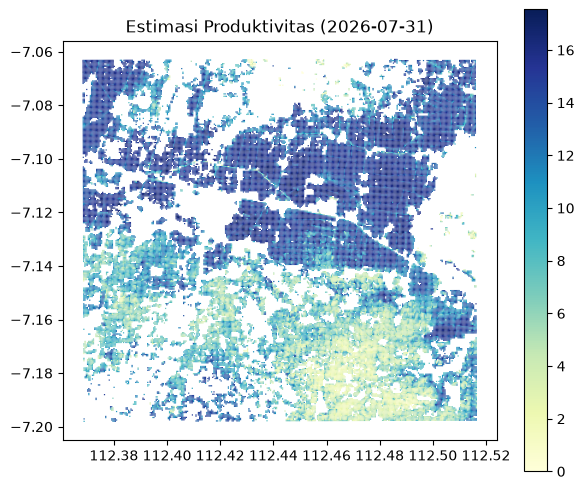

### Output 2 - Grafik Distribusi Produktivitas

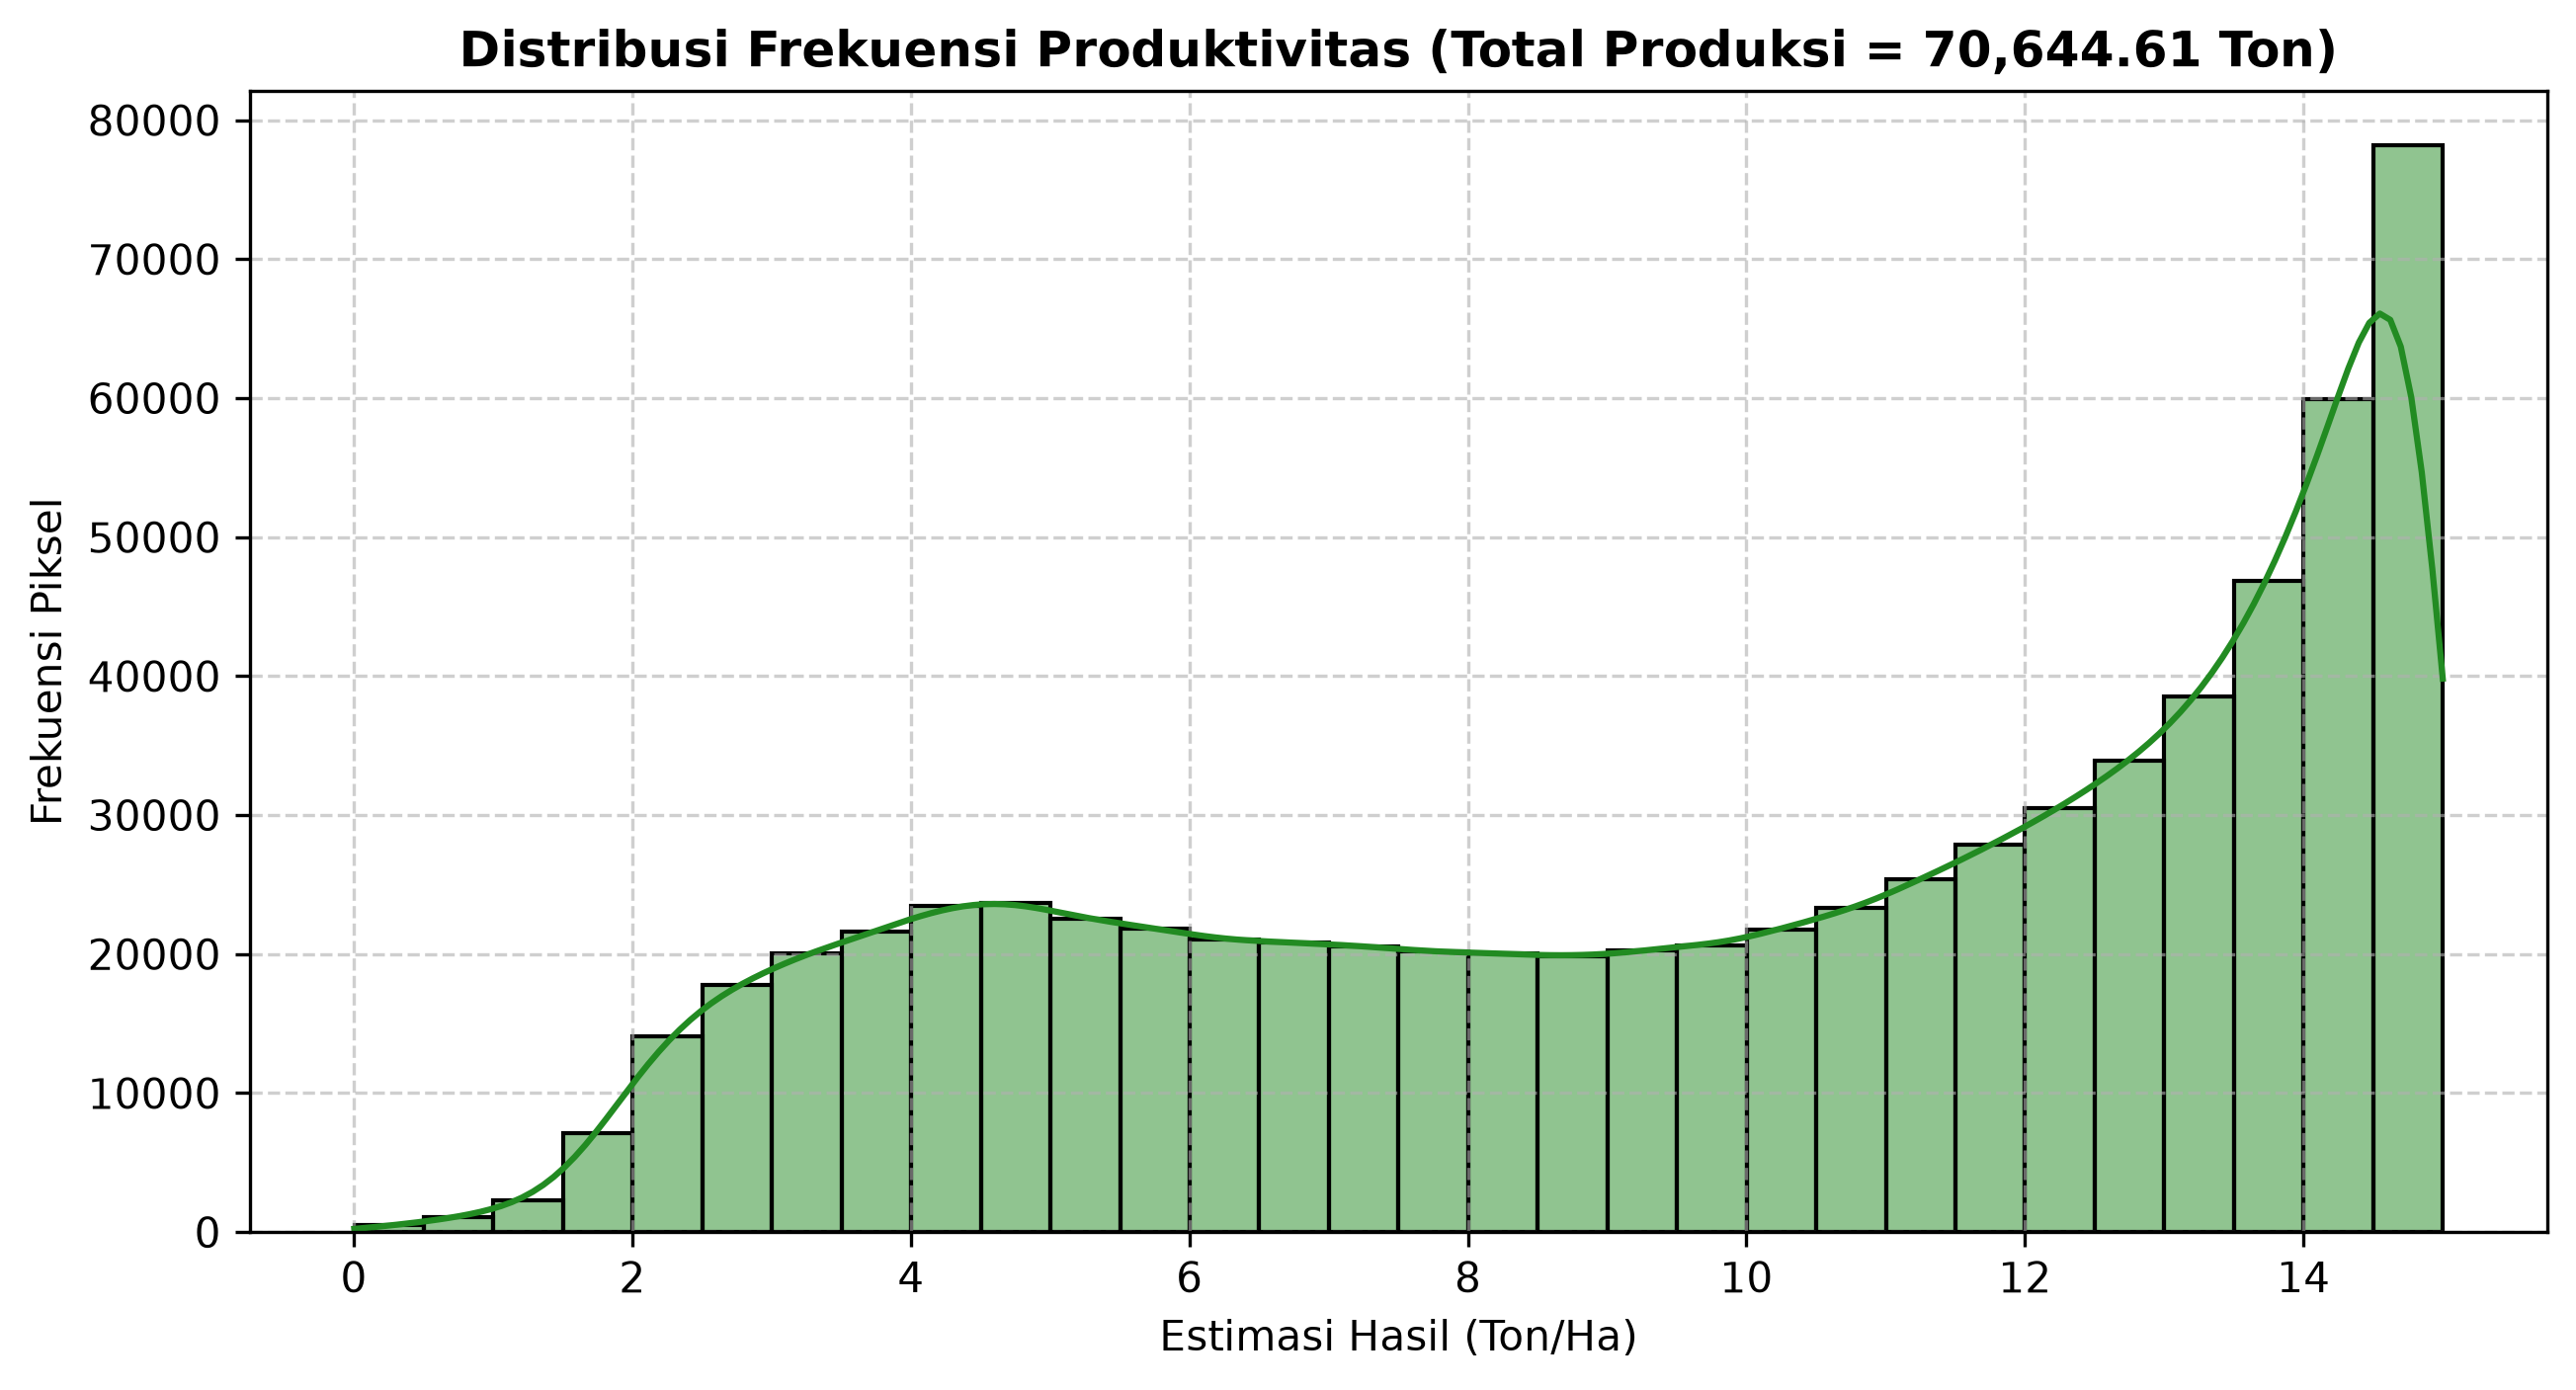

### Output 3 - GeoJSON Kelas Klasifikasi Produktivitas

,kelas,geometry
0,Rendah,"MULTIPOLYGON (((112.37034 -7.18205, 112.37052 ..."
1,Sedang,"MULTIPOLYGON (((112.36867 -7.19788, 112.36867 ..."
2,Tinggi,"MULTIPOLYGON (((112.36885 -7.19725, 112.36894 ..."


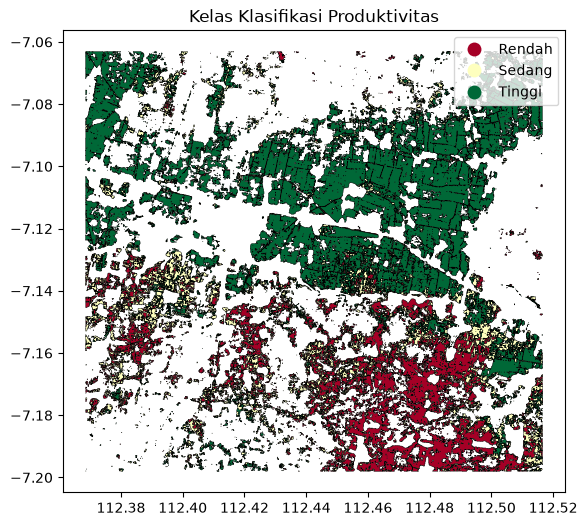

**File tersimpan:** `../../data/processed\module_4\estimasi_produktivitas_padi.geojson`, `../../results/figures/module_4\grafik_distribusi_produktivitas.png`, `../../data/processed\module_4\kelas_klasifikasi_produktivitas.geojson`


=== KALKULASI TOTAL PRODUKSI DAN RENDER SELESAI ===


In [8]:
import ee
import os
import datetime
import urllib.request
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.features import shapes
import rioxarray
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from IPython.display import Image, display, Markdown

# ==========================================
# 1. INISIALISASI & KONFIGURASI AOI
# ==========================================
ee.Authenticate()  # Jalankan jika belum autentikasi
ee.Initialize(project='poetic-emblem-487109-t6')

RAW_DIR = "../../data/raw"
PROCESSED_DIR = "../../data/processed"
FIGURES_DIR = "../../results/figures/module_4"
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

file_mask_sawah = os.path.join(PROCESSED_DIR, 'Klasifikasi_Sawah.tif')
MODULE_DIR = os.path.join(PROCESSED_DIR, "module_4")
os.makedirs(MODULE_DIR, exist_ok=True)

print("Membaca file mask sawah lokal sebagai AOI...")
mask_daerah = rioxarray.open_rasterio(file_mask_sawah)
template_2d = mask_daerah.squeeze()
bounds = mask_daerah.rio.bounds()  # (minx, miny, maxx, maxy)

mask_wgs84 = mask_daerah.rio.reproject("EPSG:4326")
wgs84_bounds = mask_wgs84.rio.bounds()
aoi_ee = ee.Geometry.Rectangle([wgs84_bounds[0], wgs84_bounds[1], wgs84_bounds[2], wgs84_bounds[3]])

# ==========================================
# 2. FUNGSI BANTUAN TILING & DOWNLOAD GEE (ROBUST)
# ==========================================
def unduh_raster_ee(ee_image, aoi_geometry, nama_file_temp, scale=10):
    print(f"Mengunduh dan menyatukan tile untuk: {nama_file_temp}...")
    bounds_geom = aoi_geometry.bounds().getInfo()['coordinates'][0]
    minx, miny = min([p[0] for p in bounds_geom]), min([p[1] for p in bounds_geom])
    maxx, maxy = max([p[0] for p in bounds_geom]), max([p[1] for p in bounds_geom])

    n_split = 4
    x_steps = np.linspace(minx, maxx, n_split + 1)
    y_steps = np.linspace(miny, maxy, n_split + 1)
    temp_files = []

    for i in range(n_split):
        for j in range(n_split):
            sub_box = ee.Geometry.Rectangle([x_steps[i], y_steps[j], x_steps[i + 1], y_steps[j + 1]])
            try:
                url = ee_image.getDownloadURL({
                    'scale': scale,
                    'crs': 'EPSG:4326',
                    'region': sub_box,
                    'format': 'GEO_TIFF'
                })
                sub_file = f"temp_tile_{i}_{j}_{nama_file_temp}"
                urllib.request.urlretrieve(url, sub_file)
                temp_files.append(sub_file)
            except Exception:
                pass

    if not temp_files:
        raise RuntimeError(f"Gagal mengunduh {nama_file_temp}. Periksa kembali koneksi GEE.")

    src_files_to_mosaic = [rasterio.open(f) for f in temp_files]
    mosaic, out_trans = merge(src_files_to_mosaic)
    meta = src_files_to_mosaic[0].meta.copy()
    for src in src_files_to_mosaic:
        src.close()

    meta.update({"height": mosaic.shape[1], "width": mosaic.shape[2], "transform": out_trans})

    with rasterio.open(nama_file_temp, "w", **meta) as dest:
        dest.write(mosaic)

    for f in temp_files:
        if os.path.exists(f):
            os.remove(f)

    da_raw = rioxarray.open_rasterio(nama_file_temp)
    da = da_raw.rio.reproject_match(mask_daerah)

    # file mentah ini hanya perantara internal, bukan output final -> hapus setelah dipakai
    da_raw.close()
    da.close()
    if os.path.exists(nama_file_temp):
        os.remove(nama_file_temp)

    return da

# ==========================================
# 3. PEMODELAN PRODUKTIVITAS LUE (LEVEL-0) DI GEE
# ==========================================
print("Menjalankan model Light Use Efficiency (LUE) untuk estimasi hasil padi...")
s2_col = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(aoi_ee) \
    .filterDate('2026-05-01', '2026-07-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))

s2_median = s2_col.median().clip(aoi_ee)
tanggal_citra = "2026-07-31"

ndvi = s2_median.normalizedDifference(['B8', 'B4'])
fpar = ndvi.multiply(1.25).subtract(0.15).clamp(0, 1)

total_par_musim = 1500.0
par_image = ee.Image.constant(total_par_musim).clip(aoi_ee)
epsilon = 1.2

gpp = par_image.multiply(fpar).multiply(epsilon)
yield_proxy = gpp.multiply(2.22).multiply(0.45).multiply(0.01).rename('Yield_Ton_Ha')

# ==========================================
# 4. UNDUH & MASKING (tidak lagi disimpan sebagai GeoTIFF final)
# ==========================================
tif_temp = "_temp_raw_download.tif"
da_raw = unduh_raster_ee(yield_proxy, aoi_ee, tif_temp, scale=10)

sawah_mask_2d = (template_2d == 1)
arr_masked = da_raw.squeeze().where(sawah_mask_2d).values

transform_masked = mask_daerah.rio.transform()
crs_masked = mask_daerah.rio.crs

valid_vals = arr_masked[~np.isnan(arr_masked)]
valid_vals = valid_vals[(valid_vals > 0) & (valid_vals < 15)]  # filter nilai wajar padi (0-15 ton/ha)

luas_per_piksel_ha = 0.01  # 10m x 10m = 100 m2 = 0.01 Ha
total_luas_sawah_ha = len(valid_vals) * luas_per_piksel_ha
rata_rata_ton_ha = float(np.nanmean(valid_vals))
total_produksi_ton = float(np.sum(valid_vals) * luas_per_piksel_ha)

print(f"\n==========================================")
print(f"HASIL ANALISIS PRODUKTIVITAS & PRODUKSI:")
print(f"* Total Luas Sawah Aktif : {total_luas_sawah_ha:,.2f} Ha")
print(f"* Rata-rata Produktivitas  : {rata_rata_ton_ha:,.2f} Ton/Ha")
print(f"* TOTAL PRODUKSI PADINYA   : {total_produksi_ton:,.2f} Ton")
print(f"==========================================")

# ==========================================
# 5. OUTPUT 1 - GEOJSON ESTIMASI PRODUKTIVITAS (nilai kontinu)
# ==========================================
# Raster 10m yang di-vectorize per-piksel akan menghasilkan GeoJSON yang sangat
# besar (ratusan ribu poligon) karena tiap piksel bernilai unik. Untuk output
# WebGIS yang ringan & tetap representatif, nilai diagregasi dulu (rata-rata
# per blok NxN piksel) sebelum divektorkan. Ubah AGGREGATION_FACTOR sesuai
# kebutuhan (1 = tanpa agregasi, per-piksel asli 10m).
AGGREGATION_FACTOR = 5  # 5x5 piksel 10m -> sel agregat 50m

print("\nMembuat GeoJSON estimasi produktivitas (nilai kontinu)...")
h, w = arr_masked.shape
h2, w2 = h // AGGREGATION_FACTOR, w // AGGREGATION_FACTOR
agg = np.full((h2, w2), np.nan, dtype="float32")
for i in range(h2):
    for j in range(w2):
        blok = arr_masked[i * AGGREGATION_FACTOR:(i + 1) * AGGREGATION_FACTOR,
                           j * AGGREGATION_FACTOR:(j + 1) * AGGREGATION_FACTOR]
        if np.sum(~np.isnan(blok)) > 0:
            agg[i, j] = float(np.nanmean(blok))

agg_transform = rasterio.Affine(
    transform_masked.a * AGGREGATION_FACTOR, transform_masked.b, transform_masked.c,
    transform_masked.d, transform_masked.e * AGGREGATION_FACTOR, transform_masked.f
)

mask_valid_agg = ~np.isnan(agg)
fitur_produktivitas = (
    {"properties": {"yield_ton_ha": round(float(v), 3)}, "geometry": geom}
    for geom, v in shapes(agg, mask=mask_valid_agg, transform=agg_transform)
)
gdf_produktivitas = gpd.GeoDataFrame.from_features(list(fitur_produktivitas), crs=crs_masked)
gdf_produktivitas = gdf_produktivitas.to_crs("EPSG:4326")

geojson_produktivitas = os.path.join(MODULE_DIR, "estimasi_produktivitas_padi.geojson")
gdf_produktivitas.to_file(geojson_produktivitas, driver="GeoJSON")
print(f"-> GeoJSON estimasi produktivitas tersimpan: {geojson_produktivitas} "
      f"({len(gdf_produktivitas)} fitur, sel {AGGREGATION_FACTOR * 10}m)")

# ==========================================
# 6. OUTPUT 3 - GEOJSON KELAS KLASIFIKASI PRODUKTIVITAS
# ==========================================
# Kelas dibuat dari kuantil data valid (33% & 66%) supaya adaptif terhadap
# sebaran nilai musim berjalan. Ganti ke ambang agronomis tetap kalau
# supervisor menghendaki kelas baku (mis. <4 / 4-6 / >6 ton/ha).
print("\nMembuat GeoJSON kelas klasifikasi produktivitas...")
q33, q66 = np.nanquantile(valid_vals, [1 / 3, 2 / 3])
label_kelas = {0: "Rendah", 1: "Sedang", 2: "Tinggi"}

kelas_arr = np.digitize(arr_masked, bins=[q33, q66])  # 0,1,2
kelas_arr_int = np.where(np.isnan(arr_masked), -1, kelas_arr).astype("int32")
mask_valid_kelas = kelas_arr_int != -1

fitur_kelas = (
    {"properties": {"kelas_id": int(v)}, "geometry": geom}
    for geom, v in shapes(kelas_arr_int, mask=mask_valid_kelas, transform=transform_masked)
)
gdf_kelas = gpd.GeoDataFrame.from_features(list(fitur_kelas), crs=crs_masked)
gdf_kelas["kelas"] = gdf_kelas["kelas_id"].map(label_kelas)
gdf_kelas = gdf_kelas.dissolve(by="kelas", as_index=False)[["kelas", "geometry"]]
gdf_kelas = gdf_kelas.to_crs("EPSG:4326")

geojson_kelas = os.path.join(MODULE_DIR, "kelas_klasifikasi_produktivitas.geojson")
gdf_kelas.to_file(geojson_kelas, driver="GeoJSON")
print(f"-> GeoJSON kelas klasifikasi tersimpan: {geojson_kelas} ({len(gdf_kelas)} fitur)")
print(f"   Ambang kelas -> Rendah: <{q33:.2f} | Sedang: {q33:.2f}-{q66:.2f} | Tinggi: >{q66:.2f} ton/ha")

# ==========================================
# 7. OUTPUT 2 - PNG GRAFIK DISTRIBUSI PRODUKTIVITAS
# ==========================================
print("\nMembuat grafik distribusi hasil...")
fig_g, ax_g = plt.subplots(figsize=(10, 5))
sns.histplot(valid_vals, kde=True, color='forestgreen', bins=30, ax=ax_g)
ax_g.set_title(f'Distribusi Frekuensi Produktivitas (Total Produksi = {total_produksi_ton:,.2f} Ton)',
               fontsize=12, fontweight='bold')
ax_g.set_xlabel('Estimasi Hasil (Ton/Ha)')
ax_g.set_ylabel('Frekuensi Piksel')
ax_g.grid(True, linestyle='--', alpha=0.6)

grafik_name = os.path.join(FIGURES_DIR, "grafik_distribusi_produktivitas.png")
plt.savefig(grafik_name, dpi=300, bbox_inches='tight')
plt.close()

# ==========================================
# 8. TAMPILKAN OUTPUT UNTUK REVIEW
# ==========================================
display(Markdown("## Hasil Kalkulasi Total Produksi Padi (Level-0 LUE)"))
display(Markdown(f"* **Total Luas Sawah Aktif:** `{total_luas_sawah_ha:,.2f} Ha`"))
display(Markdown(f"* **Rata-rata Produktivitas:** `{rata_rata_ton_ha:,.2f} Ton/Ha`"))
display(Markdown(f"* **TOTAL PRODUKSI KUMULATIF:** `{total_produksi_ton:,.2f} Ton`"))

display(Markdown("### Output 1 - GeoJSON Estimasi Produktivitas (preview atribut)"))
display(gdf_produktivitas.head())

display(Markdown("### Output 1 (peta) - Estimasi Produktivitas"))
fig1, ax1 = plt.subplots(figsize=(7, 6))
gdf_produktivitas.plot(column="yield_ton_ha", cmap="YlGnBu", legend=True, ax=ax1)
ax1.set_title(f"Estimasi Produktivitas ({tanggal_citra})")
plt.show()

display(Markdown("### Output 2 - Grafik Distribusi Produktivitas"))
display(Image(filename=grafik_name, width=800))

display(Markdown("### Output 3 - GeoJSON Kelas Klasifikasi Produktivitas"))
display(gdf_kelas)
fig2, ax2 = plt.subplots(figsize=(7, 6))
gdf_kelas.plot(column="kelas", categorical=True, legend=True,
               cmap="RdYlGn", ax=ax2, edgecolor="black", linewidth=0.3)
ax2.set_title("Kelas Klasifikasi Produktivitas")
plt.show()

display(Markdown(f"**File tersimpan:** `{geojson_produktivitas}`, `{grafik_name}`, `{geojson_kelas}`"))

print("\n=== KALKULASI TOTAL PRODUKSI DAN RENDER SELESAI ===")

# **WOFOST Potential Productivity**

In [7]:
"""
Model Estimasi Produktivitas Padi -- WOFOST (simulasi proses-fisik, open-loop)
Kabupaten Lamongan -- AOI dari Klasifikasi_15x15_Sawah_Saja.tif
==============================================================================
Level 0: TANPA data lapangan, TANPA kalibrasi lokal -- cuaca (NASA POWER),
tanah (parameter generik tekstur liat), dan kultivar padi GENERIK dari
pustaka parameter resmi WOFOST (bukan hasil fitting ke Lamongan).

Model: WOFOST 7.2 via PCSE (Python Crop Simulation Environment, Wageningen UR)
Dijalankan sebagai TITIK REPRESENTATIF (centroid AOI) -- BUKAN per piksel.

REVISI:
- TANPA PEMBERSIHAN MASK SAWAH.
- FIX Cuaca: Menggunakan NASAPowerWeatherDataProvider untuk ketersediaan
  data tahun 2026.
"""

import os
import time
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import rasterio
from pyproj import Transformer
from IPython.display import display, Markdown

import yaml
from pcse.base import ParameterProvider
from pcse.models import Wofost72_PP, Wofost72_WLP_FD
from pcse.input import (YAMLCropDataProvider, WOFOST72SiteDataProvider,
                        NASAPowerWeatherDataProvider) # <-- REVISI IMPORT

# ============================================================
# 1. KONFIGURASI
# ============================================================
PROCESSED_DIR = "../../data/processed"
FIGURES_DIR = "../../results/figures/module_4"

SAWAH_MASK_PATH = os.path.join(PROCESSED_DIR, 'Klasifikasi_Sawah.tif')
OUTPUT_DIR = os.path.join(FIGURES_DIR, 'output_wofost_true')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- musim tanam ---
PLANTING_DATE = dt.date(2026, 5, 1)   # Fase genangan awal
MAX_DURATION = 150                      # batas maksimum simulasi (hari), pengaman

# --- kultivar padi ---
CROP_NAME = 'rice'
CROP_VARIETY = 'Rice_IR64'

# --- konversi TWSO (berat kering gabah, kg/ha) ke ton GKG/ha ---
GKG_MOISTURE_FACTOR = 1.15

# --- sumber cuaca ---
WEATHER_MODEL = 'NASA_POWER' # <-- REVISI LABEL


# ============================================================
# 2. BACA MASK SAWAH (TANPA PEMBERSIHAN)
# ============================================================
def read_sawah_mask(path):
    with rasterio.open(path) as src:
        arr = src.read(1)
        res = src.res
        bounds = src.bounds
        crs = src.crs

    nodata_val = src.nodata if src.nodata is not None else 255
    nodata_mask = (arr == nodata_val)
    sawah = (arr == 1)

    # Dihitung dari raster asli (tanpa di-sieve)
    area_ha = sawah.sum() * res[0] * res[1] / 10000.0

    return {
        'area_ha': area_ha,
        'bounds': bounds,
        'crs': crs,
        'sawah_raw': np.where(nodata_mask, np.nan, sawah)
    }

def display_mask_qa(mask_info):
    """Tampilkan mask sawah asli inline untuk review -- tidak disimpan."""
    plt.figure(figsize=(7, 6))
    cmap = ListedColormap(['lightgray', 'green'])
    plt.imshow(mask_info['sawah_raw'], cmap=cmap, vmin=0, vmax=1)
    plt.title(f'Mask Sawah (Asli)\nLuas: {mask_info["area_ha"]:.1f} ha')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# ============================================================
# 3. AOI CENTROID (lon/lat) UNTUK QUERY CUACA
# ============================================================
def get_aoi_centroid_lonlat(bounds, crs):
    transformer = Transformer.from_crs(crs, 'EPSG:4326', always_xy=True)
    cx = (bounds.left + bounds.right) / 2
    cy = (bounds.bottom + bounds.top) / 2
    lon, lat = transformer.transform(cx, cy)
    return lon, lat


# ============================================================
# 4. SETUP & JALANKAN WOFOST (PP dan WLP_FD)
# ============================================================
def build_parameters():
    cropd = YAMLCropDataProvider(Wofost72_WLP_FD, force_reload=False)
    cropd.set_active_crop(CROP_NAME, CROP_VARIETY)

    soild = {
        'SMFCF': 0.45, 'SM0': 0.55, 'SMW': 0.25, 'CRAIRC': 0.05,
        'SOPE': 0.10, 'KSUB': 0.10, 'RDMSOL': 60.0, 'K0': 2.0,
        'SPADS': 0.1, 'SPODS': 0.03, 'SPASS': 0.1, 'SPOSS': 0.03,
        'DEFLIM': -0.001,
    }
    sited = WOFOST72SiteDataProvider(
        WAV=10., NOTINF=0.0, SSMAX=10., SSI=5., SMLIM=0.4, IFUNRN=0)

    return ParameterProvider(cropdata=cropd, soildata=soild, sitedata=sited)

def build_agromanagement(planting_date, max_duration):
    agro_yaml = f"""
    CropCalendar:
        crop_name: {CROP_NAME}
        variety_name: {CROP_VARIETY}
        crop_start_date: {planting_date.isoformat()}
        crop_start_type: emergence
        crop_end_date:
        crop_end_type: maturity
        max_duration: {max_duration}
    TimedEvents: null
    StateEvents: null
    """
    agro = yaml.safe_load(agro_yaml)
    return [{planting_date: agro}]

def run_scenario(model_class, parameters, weather, agro):
    sim = model_class(parameters, weather, agro)
    sim.run_till_terminate()
    df = pd.DataFrame(sim.get_output()).set_index('day')
    return df


# ============================================================
# 5. GAMBAR GABUNGAN -- SATU-SATUNYA FILE OUTPUT
# ============================================================
def build_combined_figure(df_pp, df_wlp, summary_df, area_ha, out_path):
    fig = plt.figure(figsize=(16, 9))
    gs = gridspec.GridSpec(2, 3, height_ratios=[3, 1.3], figure=fig)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(df_pp.index, df_pp['LAI'], label='Potential Production')
    ax1.plot(df_wlp.index, df_wlp['LAI'], label='Water-Limited')
    ax1.set_title('Leaf Area Index (LAI)')
    ax1.legend(); ax1.grid(alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(df_pp.index, df_pp['TWSO'], label='Potential Production')
    ax2.plot(df_wlp.index, df_wlp['TWSO'], label='Water-Limited')
    ax2.set_title('Berat kering gabah (TWSO, kg/ha)')
    ax2.legend(); ax2.grid(alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

    ax3 = fig.add_subplot(gs[0, 2])
    total_wlp = summary_df.loc[summary_df['skenario'].str.contains('Water'), 'total_produksi_ton'].iloc[0]
    total_pp = summary_df.loc[summary_df['skenario'].str.contains('Potential'), 'total_produksi_ton'].iloc[0]
    ax3.bar(['Water-Limited\n(batas bawah)', 'Potential\n(batas atas)'],
            [total_wlp, total_pp], color=['#d97706', '#16a34a'])
    ax3.set_ylabel('Total produksi AOI (ton GKG)')
    ax3.set_title(f'Rentang estimasi produksi\n({area_ha:.0f} ha sawah)')
    ax3.grid(alpha=0.3, axis='y')

    ax_table = fig.add_subplot(gs[1, :])
    ax_table.axis('off')
    tbl = ax_table.table(
        cellText=summary_df.values,
        colLabels=summary_df.columns,
        loc='center', cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.8)

    fig.suptitle(f'Hasil Estimasi Produktivitas Padi -- WOFOST 7.2 (Level 0)\n'
                 f'Tanam: {PLANTING_DATE.isoformat()} | Cuaca: {WEATHER_MODEL}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    return fig


# ============================================================
# 6. MAIN
# ============================================================
if __name__ == '__main__':
    print('=== 1. Membaca mask sawah (TANPA pembersihan) ===')
    mask_info = read_sawah_mask(SAWAH_MASK_PATH)
    print(f"Luas sawah (asli): {mask_info['area_ha']:.1f} ha")

    print('\n=== 2. Menentukan titik representatif AOI & mengambil cuaca ===')
    lon, lat = get_aoi_centroid_lonlat(mask_info['bounds'], mask_info['crs'])
    print(f'Centroid AOI (lon, lat): {lon:.5f}, {lat:.5f}')

    max_retries = 3
    weather = None

    # <-- REVISI PADA PENGAMBILAN DATA CUACA -->
    for attempt in range(max_retries):
        try:
            print(f"Mencoba unduh cuaca {WEATHER_MODEL} (Percobaan {attempt+1}/{max_retries})...")
            weather = NASAPowerWeatherDataProvider(
                latitude=lat,
                longitude=lon
            )
            print("Berhasil mengunduh data cuaca dari NASA POWER!")
            break
        except Exception as e:
            print(f"Gagal mengambil cuaca (Timeout/Error): {e}")
            if attempt < max_retries - 1:
                print("Menunggu 5 detik sebelum mencoba lagi...")
                time.sleep(5)
            else:
                raise RuntimeError("Gagal mengambil data dari NASA POWER.")

    print('\n=== 3. Parameter model (kultivar, tanah, site) ===')
    parameters = build_parameters()
    agro = build_agromanagement(PLANTING_DATE, MAX_DURATION)

    print('\n=== 4. Menjalankan skenario Potential Production (batas atas) ===')
    df_pp = run_scenario(Wofost72_PP, parameters, weather, agro)
    twso_pp = df_pp['TWSO'].iloc[-1]
    print(f'TWSO Potential Production: {twso_pp:.0f} kg/ha (dry matter)')

    print('\n=== 5. Menjalankan skenario Water-Limited (batas bawah) ===')
    df_wlp = run_scenario(Wofost72_WLP_FD, parameters, weather, agro)
    twso_wlp = df_wlp['TWSO'].iloc[-1]
    print(f'TWSO Water-Limited: {twso_wlp:.0f} kg/ha (dry matter)')

    print('\n=== 6. Konversi ke estimasi produksi total AOI ===')
    ton_ha_pp = twso_pp / 1000.0 * GKG_MOISTURE_FACTOR
    ton_ha_wlp = twso_wlp / 1000.0 * GKG_MOISTURE_FACTOR
    total_ton_pp = ton_ha_pp * mask_info['area_ha']
    total_ton_wlp = ton_ha_wlp * mask_info['area_ha']

    summary = pd.DataFrame([
        {'skenario': 'Potential Production (batas atas, setara irigasi penuh)',
         'yield_ton_ha_GKG': round(ton_ha_pp, 2),
         'luas_sawah_ha': round(mask_info['area_ha'], 1),
         'total_produksi_ton': round(total_ton_pp, 0)},
        {'skenario': 'Water-Limited (batas bawah, setara tadah hujan)',
         'yield_ton_ha_GKG': round(ton_ha_wlp, 2),
         'luas_sawah_ha': round(mask_info['area_ha'], 1),
         'total_produksi_ton': round(total_ton_wlp, 0)},
    ])

    print('\n=== 7. Membuat gambar hasil gabungan (satu-satunya file output) ===')
    out_png = os.path.join(OUTPUT_DIR, f'hasil_wofost_{PLANTING_DATE}.png')
    build_combined_figure(df_pp, df_wlp, summary, mask_info['area_ha'], out_png)
    print(f'-> File output tersimpan: {out_png}')

    # ============================================================
    # 8. TAMPILKAN UNTUK REVIEW (inline, tidak disimpan terpisah)
    # ============================================================
    display(Markdown('## Review -- Mask Sawah (Asli)'))
    display_mask_qa(mask_info)

    display(Markdown('## Review -- Ringkasan Hasil WOFOST'))
    display(summary)

    display(Markdown('## Review -- Gambar Hasil (file output)'))
    plt.show()

    print(f"""
=== RINGKASAN ===
Luas sawah (asli tanpa dibersihkan) : {mask_info['area_ha']:.1f} ha
Rentang produktivitas             : {ton_ha_wlp:.2f} - {ton_ha_pp:.2f} ton GKG/ha
Rentang total produksi AOI        : {total_ton_wlp:.0f} - {total_ton_pp:.0f} ton GKG
""")

=== 1. Membaca mask sawah (TANPA pembersihan) ===
Luas sawah (asli): 9990.1 ha

=== 2. Menentukan titik representatif AOI & mengambil cuaca ===
Centroid AOI (lon, lat): 112.44257, -7.13051
Mencoba unduh cuaca NASA_POWER (Percobaan 1/3)...


KeyboardInterrupt: 